# Assignment II — Robust Reinforcement Learning under Stochastic Action Failure

**Group Contribution Declaration**

| Name | Roll No. | Contribution (%) |
|---|---|---|
| Aishwarya G M | 2025AA05151 | 100 |
| Amit Pandey | 2025AA05184 | 100 |
| Aditya  | 2025AB05080 | 100 |
| Ranjan Basak | 2025AA05709 | 100 |
| Murlidhar Pandey | 2025AA05182 | 100 |

We have implemented:

- **(a)** A `gym.Wrapper` modifying `LunarLander-v3` according to assignment instructions.
- **(b)** A Deep Q-Network (DQN) agent, trained on both the original and the modified environment.
- **(c)** A Double DQN (DDQN) agent, trained on both the original and the modified environment.
- **(d)** Comparison plots for the four trained agents (DQN/DDQN × original/modified).
- **(e)** Discussion and answering the assignment's analysis questions.

In [1]:
from datetime import datetime      
print("Execution timestamp :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
import socket
print("Machine hostname    :", socket.gethostname())   
print("-" * 55)

Execution timestamp : 2026-08-06 23:22:47
Machine hostname    : 2025aa05151
-------------------------------------------------------


## 0. Setup

In [2]:
!pip install "gymnasium[box2d]" box2d -q

In [3]:
import random
from collections import deque, namedtuple
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# same seed for reproducibilty
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

Using device: cpu


## (a) Modified Environment: Implementation and Verification

We have modified `LunarLander-v3` environment as per following steps:
- agent randomly performs action=0 15%, if selected action is not 0.
- Calculate the reward based on given formula: `R = R_base − 0.3·1[a ∈ {1,2,3}] + bonus`
- bonus=50 for safe landing, 0 otherwise
- Landing is safe only when `v_horizontal < 0.1, v_vertical < 0.1, orientation_angle < 0.1` and left and right leg are in landing area.

In [4]:
class StochasticLunarLander(gym.Wrapper):

    def __init__(self, env, failure_prob=0.15, fuel_penalty=0.3, landing_bonus=50.0):
        super().__init__(env)
        self.failure_prob = failure_prob
        self.fuel_penalty = fuel_penalty
        self.landing_bonus = landing_bonus

        self.stats = {"thruster_attempts": 0, "misfires": 0, "landing_bonus_awarded": 0}
        self._last_decomposition = None

    @staticmethod
    def is_safe_landing(obs, terminated, truncated):
        """True iff the episode ended in a controlled landing on both legs."""
        if not terminated or truncated:
            return False
        left_leg, right_leg = obs[6], obs[7]
        vx, vy, theta = obs[2], obs[3], obs[4]
        return (
            left_leg == 1 and right_leg == 1
            and abs(vx) < 0.10 and abs(vy) < 0.10 and abs(theta) < 0.10
        )

    def step(self, action):
        a = int(action) 

        # simulate intermittent engine failure
        if a == 0:
            a_exec = 0
        else:
            self.stats["thruster_attempts"] += 1
            r = np.random.uniform(0.0, 1.0)
            if r < self.failure_prob:
                a_exec = 0
                self.stats["misfires"] += 1
            else:
                a_exec = a

        # execute action on base environment
        obs, r_base, terminated, truncated, info = self.env.step(a_exec)

        # fuel penalty
        indicator = 1.0 if a in (1, 2, 3) else 0.0
        fuel_penalty_applied = self.fuel_penalty * indicator
        reward = r_base - fuel_penalty_applied

        # safe-landing bonus
        bonus = 0.0
        if self.is_safe_landing(obs, terminated, truncated):
            bonus = self.landing_bonus
            self.stats["landing_bonus_awarded"] += 1
        reward += bonus

        self._last_decomposition = {
            "a": a, "a_exec": a_exec, "r_base": r_base,
            "fuel_penalty_applied": fuel_penalty_applied, "bonus_applied": bonus,
        }

        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)


### Verification
We are running a random policy and logging, and verifying if behaviour is as expected.

In [5]:
def run_random_policy_verification(num_episodes=500, seed=SEED):
    env = StochasticLunarLander(gym.make("LunarLander-v3"))
    rows = []
    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        while not (terminated or truncated):
            a = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(a)
            d = env._last_decomposition
            rows.append({
                "episode": ep,
                "a": d["a"],
                "a_exec": d["a_exec"],
                "was_thruster": d["a"] in (1, 2, 3),
                "misfired": d["a"] in (1, 2, 3) and d["a_exec"] == 0,
                "r_base": d["r_base"],
                "fuel_penalty_applied": d["fuel_penalty_applied"],
                "bonus_applied": d["bonus_applied"],
                "reward": reward,
                "terminated": terminated,
                "truncated": truncated,
            })
    env.close()
    return pd.DataFrame(rows), env.stats

log_df, stats = run_random_policy_verification(num_episodes=500)
print(stats)
log_df.head()


{'thruster_attempts': 33682, 'misfires': 5048, 'landing_bonus_awarded': 17}


,episode,a,a_exec,was_thruster,misfired,r_base,fuel_penalty_applied,bonus_applied,reward,terminated,truncated
0,0,2,2,True,False,-2.497033,0.3,0.0,-2.797033,False,False
1,0,1,1,True,False,1.807542,0.3,0.0,1.507542,False,False
2,0,1,1,True,False,2.151316,0.3,0.0,1.851316,False,False
3,0,0,0,False,False,1.636452,0.0,0.0,1.636452,False,False
4,0,2,2,True,False,-3.114155,0.3,0.0,-3.414155,False,False


##### Check 1 — approximately 15% of thruster actions are replaced by Do Nothing

Thruster attempts logged: 33682
Misfires (replaced by Do Nothing): 5048
Misfire rate: 0.1499  (expected ~0.15)
95% CI: [0.1461, 0.1537]


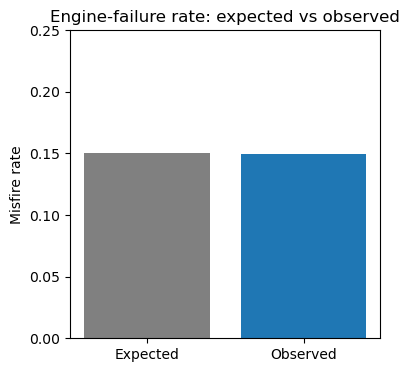

In [6]:
thruster_df = log_df[log_df["was_thruster"]]
misfire_rate = thruster_df["misfired"].mean()
print(f"Thruster attempts logged: {len(thruster_df)}")
print(f"Misfires (replaced by Do Nothing): {thruster_df['misfired'].sum()}")
print(f"Misfire rate: {misfire_rate:.4f}  (expected ~0.15)")

n = len(thruster_df)
se = np.sqrt(misfire_rate * (1 - misfire_rate) / n)
print(f"95% CI: [{misfire_rate - 1.96*se:.4f}, {misfire_rate + 1.96*se:.4f}]")

plt.figure(figsize=(4, 4))
plt.bar(["Expected", "Observed"], [0.15, misfire_rate], color=["gray", "tab:blue"])
plt.ylabel("Misfire rate")
plt.title("Engine-failure rate: expected vs observed")
plt.ylim(0, 0.25)
plt.show()


##### Check 2 — fuel penalty is charged on every attempted thruster action, fired or misfired

In [7]:
penalty_by_outcome = thruster_df.groupby("misfired")["fuel_penalty_applied"].agg(["mean", "min", "max", "count"])
penalty_by_outcome.index = penalty_by_outcome.index.map({True: "misfired -> a_exec=0", False: "fired normally"})
print(penalty_by_outcome)

assert np.allclose(thruster_df["fuel_penalty_applied"], 0.3), "Fuel penalty was not exactly 0.3 for some thruster attempt"
do_nothing_df = log_df[~log_df["was_thruster"]]
assert np.allclose(do_nothing_df["fuel_penalty_applied"], 0.0), "A Do-Nothing action was incorrectly penalised"
print("\nConfirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are not penalised.")


                      mean  min  max  count
misfired                                   
fired normally         0.3  0.3  0.3  28634
misfired -> a_exec=0   0.3  0.3  0.3   5048

Confirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are not penalised.


#### Check 3 — the +50 landing bonus is awarded only when the safe-landing criteria hold

In [8]:
bonus_rows = log_df[log_df["bonus_applied"] > 0]
print(f"Total bonus-awarding steps: {len(bonus_rows)}")
print(f"Total times bonus awarded: {stats['landing_bonus_awarded']}")

# every bonus step must be a terminated (not truncated) step
assert bonus_rows["terminated"].all() and (~bonus_rows["truncated"]).all()
print("Confirmed: bonus only ever appears on terminated, non-truncated steps.")

Total bonus-awarding steps: 17
Total times bonus awarded: 17
Confirmed: bonus only ever appears on terminated, non-truncated steps.


Above checks ensure the StochasticLunarLander modified environment behaves exactly as we intend for it to, and doesnt do any other state / reward changes.

## DQN and DDQN Agents

Both agents share the same network architecture, optimizer, replay buffer, ε-greedy schedule, seed and hyperparameters.
- `train_dqn(..., double_dqn=False)` trains a vanilla DQN;
- `train_dqn(..., double_dqn=True)` trains a DDQN by changing only the target-Q computation.

Here we decouple action selection from action evaluation using the online network.

In [9]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    # Fixed-capacity FIFO experience replay buffer with uniform random sampling.
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    # Simple MLP, it has 1 input layer (8-dim LunarLander state),1 hidden layer, 1 output layer (4 action)
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


In [10]:
# Hyperparameters shared identically across DQN/DDQN and original/modified environment runs.
HYPERPARAMS = dict(
    num_episodes=800,
    max_steps=1000,
    gamma=0.99,
    lr=5e-4,
    batch_size=64,
    buffer_capacity=100000, # Max steps in an episode
    min_buffer_size=1000, # Initial exploration steps
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    target_update_every=10,
    hidden_dim=128, # hidden layer size of MLP in DDQN
)


### Fixed validation state set
Here we have:
- sampled once from the original environment under a random policy
- reused it to evaluate *every* agent throughout training

Therefore the reported Q-values are comparable across runs.

In [11]:
def build_validation_states(num_states=200, seed=SEED):
    env = gym.make("LunarLander-v3")
    states = []
    obs, info = env.reset(seed=seed)
    while len(states) < num_states:
        a = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(a)
        states.append(np.array(obs, dtype=np.float32))
        if terminated or truncated:
            obs, info = env.reset(seed=seed + len(states))
    env.close()
    return np.stack(states)

VALIDATION_STATES = build_validation_states()
print("Validation set shape:", VALIDATION_STATES.shape)


Validation set shape: (200, 8)


In [12]:
def train_dqn(env_fn, seed, double_dqn, hyperparams=HYPERPARAMS, validation_states=VALIDATION_STATES, label=""):
    # Function trains DQN and DDQN agent
    # env_fn is callable returns environment instance
    # double_dqn = True for DDQN, false for DQN
    # Return a dictionary of per-episode metrics

    set_seed(seed)
    env = env_fn()
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=hyperparams["lr"])
    buffer = ReplayBuffer(hyperparams["buffer_capacity"])
    val_states_t = torch.tensor(validation_states, dtype=torch.float32, device=device)

    epsilon = hyperparams["eps_start"]
    history = {
        "episode_reward": [], "avg_q_value": [], "landing_success": [],
        "landing_success_ma100": [], "thruster_activations": [],
    }

    for episode in range(hyperparams["num_episodes"]):
        obs, info = env.reset(seed=seed + episode)
        state = np.array(obs, dtype=np.float32)
        ep_reward, thruster_count, steps = 0.0, 0, 0
        terminated = truncated = False

        while not (terminated or truncated) and steps < hyperparams["max_steps"]:
            steps += 1
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.from_numpy(state).unsqueeze(0).to(device)
                    action = int(q_net(state_t).argmax(dim=1).item())

            if action in (1, 2, 3):
                thruster_count += 1

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array(next_obs, dtype=np.float32)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            ep_reward += reward

            if len(buffer) >= hyperparams["min_buffer_size"]:
                batch = buffer.sample(hyperparams["batch_size"])
                states_b = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions_b = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
                rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states_b = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones_b = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

                q_values = q_net(states_b).gather(1, actions_b)

                with torch.no_grad():
                    if double_dqn: # DDQN
                        next_actions = q_net(next_states_b).argmax(dim=1, keepdim=True)
                        next_q = target_net(next_states_b).gather(1, next_actions)
                    else: # DQN
                        next_q = target_net(next_states_b).max(dim=1, keepdim=True)[0]
                    target_q = rewards_b + hyperparams["gamma"] * next_q * (1 - dones_b)

                loss = nn.functional.smooth_l1_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(hyperparams["eps_end"], epsilon * hyperparams["eps_decay"])
        if episode % hyperparams["target_update_every"] == 0:
            target_net.load_state_dict(q_net.state_dict())

        success = int(StochasticLunarLander.is_safe_landing(state, terminated, truncated))

        with torch.no_grad():
            avg_q = q_net(val_states_t).max(dim=1)[0].mean().item()

        history["episode_reward"].append(ep_reward)
        history["avg_q_value"].append(avg_q)
        history["landing_success"].append(success)
        history["thruster_activations"].append(thruster_count)
        window = history["landing_success"][-100:]
        history["landing_success_ma100"].append(sum(window) / len(window))

        if episode % 50 == 0:
            print(f"[{label}] ep {episode:4d}  reward {ep_reward:8.2f}  "
                  f"avgQ {avg_q:7.2f}  success_ma100 {history['landing_success_ma100'][-1]:.2f}  eps {epsilon:.3f}")

    env.close()
    return history, q_net


### Train the four agents

We train all four combination here. All four runs use the identical hyperparameters and the identical seed.

In [ ]:
# Function to return original environment instance
def make_original():
    return gym.make("LunarLander-v3")

# Function to return modified environment instance
def make_modified():
    return StochasticLunarLander(gym.make("LunarLander-v3"))

results = {}
results["DQN_original"]  = train_dqn(make_original, seed=SEED, double_dqn=False, label="DQN-orig")
results["DDQN_original"] = train_dqn(make_original, seed=SEED, double_dqn=True,  label="DDQN-orig")
results["DQN_modified"]  = train_dqn(make_modified, seed=SEED, double_dqn=False, label="DQN-mod")
results["DDQN_modified"] = train_dqn(make_modified, seed=SEED, double_dqn=True,  label="DDQN-mod")

print("Training complete for:", list(results.keys()))


[DQN-orig] ep    0  reward  -375.15  avgQ    0.10  success_ma100 0.00  eps 0.995
[DQN-orig] ep   50  reward  -115.33  avgQ    1.57  success_ma100 0.00  eps 0.774
[DQN-orig] ep  100  reward   -67.00  avgQ    4.20  success_ma100 0.00  eps 0.603
[DQN-orig] ep  150  reward    -6.55  avgQ    9.07  success_ma100 0.01  eps 0.469
[DQN-orig] ep  200  reward    22.48  avgQ   13.93  success_ma100 0.01  eps 0.365
[DQN-orig] ep  250  reward    -7.23  avgQ   20.70  success_ma100 0.00  eps 0.284


In [ ]:
# Save trained models + histories for faster rerun
import pickle

histories = {name: h for name, (h, _net) in results.items()}
with open("training_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, (_h, net) in results.items():
    torch.save(net.state_dict(), f"{name}_qnet.pt")

print(f"Saved histories to training_histories.pkl and network weights to {name}_qnet.pt")


## (d) Performance Evaluation

We are showing four plots:
- Episode reward versus training episode
- Average predicted Q-value versus training episode
- Successful landing rate versus training episode
- Average number of thruster activations per episode versus training episode

For all four agents.

In [ ]:
LABELS = {
    "DQN_original": "DQN - Original",
    "DDQN_original": "DDQN - Original",
    "DQN_modified": "DQN - Modified",
    "DDQN_modified": "DDQN - Modified",
}
COLORS = {
    "DQN_original": "tab:blue",
    "DDQN_original": "tab:orange",
    "DQN_modified": "tab:green",
    "DDQN_modified": "tab:red",
}

def smooth(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def plot_metric(metric_key, title, ylabel, smoothed=False):
    plt.figure(figsize=(8, 5))
    for name, (history, _net) in results.items():
        y = history[metric_key]
        if smoothed:
            y = smooth(y)
            x = np.arange(len(y)) + (len(history[metric_key]) - len(y))
        else:
            x = np.arange(len(y))
        plt.plot(x, y, label=LABELS[name], color=COLORS[name])
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
plot_metric("episode_reward", "Episode reward vs training episode (smoothed)", "Episode reward", smoothed=True)

In [ ]:
plot_metric("avg_q_value", "Average predicted Q-value (fixed validation set) vs training episode", "Avg predicted Q-value")

In [ ]:
plot_metric("landing_success_ma100", "Successful landing rate (100-episode moving average) vs training episode", "Landing success rate")

In [ ]:
plot_metric("thruster_activations", "Average thruster activations per episode vs training episode (smoothed)", "Thruster activations / episode", smoothed=True)

**Interpretation (fill in after inspecting the plots above):**[TODO]

- *Episode reward:* ...
- *Average predicted Q-value:* ...
- *Successful landing rate:* ...
- *Thruster activations per episode:* ...

## (e) Discussion

Answer using the plots and numbers produced above.

**1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN? Justify using the Q-value plots.**

[TODO]_Your answer here. Hint: compare `avg_q_value` for DQN-modified vs DDQN-modified against DQN-original vs DDQN-original — a larger gap under the modified environment would indicate the added stochasticity amplifies DQN's overestimation bias, which DDQN is designed to correct._

**2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?**

The agent's chosen action and the action actually executed can differ, so the same state–action pair the agent updates towards can lead to different outcomes purely due to the 15% failure roll, weakening the causal link the Bellman update assumes between a state, an action, and the resulting reward/next-state.

**3. Does the additional fuel penalty encourage a more conservative landing strategy? Support with experimental evidence.**

In the thruster-activations-per-episode plot — a downward trend or lower steady-state value is observed for the modified environment relative to the original environment - indicating a conservative approach taken by the modified env's agent policy.

**4. Which algorithm performs better under stochastic engine failures? Is this consistent with the theoretical advantage of DDQN over DQN?**

[TODO] compare final/steady-state episode reward and landing-success rate for DQN-modified vs DDQN-modified.

**5. Identify one limitation of your experimental setup and suggest one possible improvement.**

Single-seed training (no variance estimate across seeds), <br>
fixed hyperparameters not separately tuned per environment, <br>
limited episode budget, <br>
MLP-only architecture, etc.